# Telecom Customer Churn & Retention
## 06 — Retention Strategy

This notebook converts churn predictions into a practical customer-retention framework.

The core idea is:

**Churn Risk + Customer Value + Customer Characteristics → Retention Priority**

The notebook will:

- combine predicted churn probability with CLTV;
- create churn-risk bands;
- create customer-value segments;
- assign retention-priority tiers;
- identify the highest-priority customers;
- attach simple, interpretable retention recommendations;
- summarize the potential customer value exposed to churn risk;
- export an actionable retention list for business use.

### Note
The model estimates the probability that a customer will churn based on historical patterns.

These probabilities are **predictive**, not causal.  
The recommended actions in this notebook are business rules designed for portfolio analysis and should be validated through experiments such as A/B tests before real deployment.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 1. Load model predictions, test-set value data, and customer attributes


In [2]:
candidate_prediction_paths = [
    Path("../outputs/predictions/customer_churn_predictions.csv"),
    Path("outputs/predictions/customer_churn_predictions.csv"),
    Path("customer_churn_predictions.csv"),
    Path("/mnt/data/outputs/predictions/customer_churn_predictions.csv"),
]

candidate_value_paths = [
    Path("../data/processed/test_customer_value.csv"),
    Path("data/processed/test_customer_value.csv"),
    Path("test_customer_value.csv"),
    Path("/mnt/data/processed/test_customer_value.csv"),
]

candidate_cleaned_paths = [
    Path("../data/processed/telco_churn_cleaned.csv"),
    Path("data/processed/telco_churn_cleaned.csv"),
    Path("telco_churn_cleaned.csv"),
    Path("/mnt/data/processed/telco_churn_cleaned.csv"),
]

PREDICTION_PATH = next((p for p in candidate_prediction_paths if p.exists()), None)
VALUE_PATH = next((p for p in candidate_value_paths if p.exists()), None)
CLEANED_PATH = next((p for p in candidate_cleaned_paths if p.exists()), None)

if PREDICTION_PATH is None:
    raise FileNotFoundError(
        "customer_churn_predictions.csv was not found. "
        "Run 05_churn_modeling.ipynb first."
    )

if VALUE_PATH is None:
    raise FileNotFoundError(
        "test_customer_value.csv was not found. "
        "Run 04_feature_engineering.ipynb first."
    )

if CLEANED_PATH is None:
    raise FileNotFoundError(
        "telco_churn_cleaned.csv was not found. "
        "Run 01_data_preparation.ipynb first."
    )

predictions = pd.read_csv(PREDICTION_PATH)
test_value = pd.read_csv(VALUE_PATH)
customers = pd.read_csv(CLEANED_PATH)

print(f"Predictions: {PREDICTION_PATH}")
print(f"Customer value: {VALUE_PATH}")
print(f"Cleaned customer data: {CLEANED_PATH}")


Predictions: outputs/predictions/customer_churn_predictions.csv
Customer value: ../data/processed/test_customer_value.csv
Cleaned customer data: ../data/processed/telco_churn_cleaned.csv


## 2. Merge predictions with CLTV and customer attributes


In [4]:
customer_attributes = customers.reset_index().rename(
    columns={"index": "source_index"}
)

retention_df = (
    predictions
    .merge(
        test_value[["source_index", "CLTV"]],
        on="source_index",
        how="left"
    )
    .merge(
        customer_attributes[[
            "source_index",
            "CustomerID",
            "Gender",
            "Senior Citizen",
            "Partner",
            "Dependents",
            "Tenure Months",
            "Internet Service",
            "Online Security",
            "Online Backup",
            "Device Protection",
            "Tech Support",
            "Contract",
            "Paperless Billing",
            "Payment Method",
            "Monthly Charges",
            "Total Charges",
        ]],
        on="source_index",
        how="left"
    )
)

print(f"Retention records: {len(retention_df):,}")
retention_df.head()


Retention records: 1,409


,source_index,actual_churn,predicted_churn,churn_probability,risk_level,CLTV,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,684,1,1,0.930,High,2487,6861-XWTWQ,Male,Yes,Yes,No,7,Fiber optic,No,No,Yes,No,Month-to-month,Yes,Electronic check,99.250,665.450
1,1203,1,1,0.923,High,2975,1069-XAIEM,Female,Yes,No,No,1,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,85.050,85.050
2,1756,1,1,0.922,High,3763,9248-OJYKK,Male,Yes,No,No,1,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,76.450,76.450
3,1818,1,1,0.922,High,5962,0295-PPHDO,Male,No,No,No,1,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,95.450,95.450
4,886,1,1,0.915,High,5795,5178-LMXOP,Male,Yes,Yes,No,1,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,95.100,95.100


## 3. Define churn-risk segments

The prediction model produces a probability between 0 and 1.

For this project, customers are grouped into:

- **Low Risk:** below 30%
- **Medium Risk:** 30% to below 60%
- **High Risk:** 60% or higher


In [6]:
retention_df["Risk Segment"] = pd.cut(
    retention_df["churn_probability"],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    right=False,
)

risk_summary = (
    retention_df.groupby("Risk Segment", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        actual_churners=("actual_churn", "sum"),
        avg_cltv=("CLTV", "mean"),
    )
)

risk_summary["actual_churn_rate"] = (
    risk_summary["actual_churners"] / risk_summary["customers"]
)

risk_summary


,customers,avg_churn_probability,actual_churners,avg_cltv,actual_churn_rate
Risk Segment,,,,,
Low Risk,881,0.088,87,"4,578.561",0.099
Medium Risk,325,0.447,134,"4,167.849",0.412
High Risk,203,0.742,153,"3,893.187",0.754


## 4. Define customer-value segments using CLTV

CLTV is divided into three groups based on the test-set distribution:

- **Low Value:** bottom third
- **Medium Value:** middle third
- **High Value:** top third

In [7]:
low_value_cutoff = retention_df["CLTV"].quantile(1/3)
high_value_cutoff = retention_df["CLTV"].quantile(2/3)

def assign_value_segment(cltv):
    if cltv < low_value_cutoff:
        return "Low Value"
    elif cltv < high_value_cutoff:
        return "Medium Value"
    else:
        return "High Value"

retention_df["Value Segment"] = retention_df["CLTV"].apply(assign_value_segment)

print(f"Low/Medium cutoff:  {low_value_cutoff:,.0f}")
print(f"Medium/High cutoff: {high_value_cutoff:,.0f}")

retention_df["Value Segment"].value_counts()


Low/Medium cutoff:  4,003
Medium/High cutoff: 5,076


Value Segment
High Value      470
Medium Value    470
Low Value       469
Name: count, dtype: int64

## 5. Create a retention-priority framework

Priority is based on both churn risk and customer value.

| Churn Risk | Customer Value | Retention Priority |
|---|---|---|
| High | High | Critical |
| High | Medium | High |
| Medium | High | High |
| High | Low | Medium |
| Medium | Medium | Medium |
| Medium | Low | Low |
| Low | Any | Low |

The purpose is to focus scarce retention resources on customers where both the **likelihood of churn** and the **value at risk** are meaningful.


In [8]:
def assign_priority(row):
    risk = row["Risk Segment"]
    value = row["Value Segment"]

    if risk == "High Risk" and value == "High Value":
        return "Critical"
    elif (
        (risk == "High Risk" and value == "Medium Value")
        or (risk == "Medium Risk" and value == "High Value")
    ):
        return "High"
    elif (
        (risk == "High Risk" and value == "Low Value")
        or (risk == "Medium Risk" and value == "Medium Value")
    ):
        return "Medium"
    else:
        return "Low"

retention_df["Retention Priority"] = retention_df.apply(
    assign_priority,
    axis=1
)

priority_order = ["Critical", "High", "Medium", "Low"]

retention_df["Retention Priority"] = pd.Categorical(
    retention_df["Retention Priority"],
    categories=priority_order,
    ordered=True
)

retention_df["Retention Priority"].value_counts().reindex(priority_order)


Retention Priority
Critical      47
High         135
Medium       209
Low         1018
Name: count, dtype: int64

## 6. Quantify customer value exposed to churn risk

**Expected CLTV at Risk = Predicted Churn Probability × CLTV**


In [9]:
retention_df["Expected CLTV at Risk"] = (
    retention_df["churn_probability"] * retention_df["CLTV"]
)

priority_summary = (
    retention_df.groupby("Retention Priority", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_cltv=("CLTV", "mean"),
        total_cltv=("CLTV", "sum"),
        expected_cltv_at_risk=("Expected CLTV at Risk", "sum"),
        actual_churners=("actual_churn", "sum"),
    )
    .reindex(priority_order)
)

priority_summary["actual_churn_rate"] = (
    priority_summary["actual_churners"] / priority_summary["customers"]
)

priority_summary


,customers,avg_churn_probability,avg_cltv,total_cltv,expected_cltv_at_risk,actual_churners,actual_churn_rate
Retention Priority,,,,,,,
Critical,47,0.732,"5,531.574",259984,"190,378.516",32,0.681
High,135,0.551,"5,205.141",702694,"376,402.304",75,0.556
Medium,209,0.599,"3,692.876",771811,"437,625.989",122,0.584
Low,1018,0.137,"4,365.512",4444091,"528,516.996",145,0.142


## 7. Visualize retention-priority groups


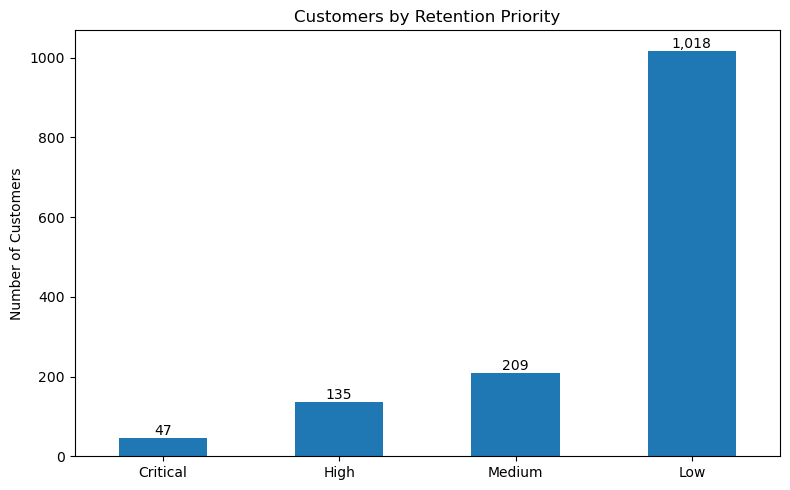

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

priority_counts = (
    retention_df["Retention Priority"]
    .value_counts()
    .reindex(priority_order)
)

priority_counts.plot(kind="bar", ax=ax)

ax.set_title("Customers by Retention Priority")
ax.set_xlabel("")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(priority_counts):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## 8. Identify key customer risk factors

The predictive model produces churn probabilities, but retention teams also need a simple explanation of what may be contributing to a customer's risk.

The rules below focus on patterns identified during EDA:

- month-to-month contract;
- short tenure;
- electronic-check payment;
- fiber-optic service;
- lack of tech support;
- lack of online security;
- relatively high monthly charges.

These are descriptive risk indicators, not causal explanations.


In [11]:
monthly_charge_high_cutoff = customers["Monthly Charges"].quantile(0.75)

def identify_risk_factors(row):
    factors = []

    if row["Contract"] == "Month-to-month":
        factors.append("Month-to-month contract")

    if row["Tenure Months"] <= 6:
        factors.append("Short tenure")

    if row["Payment Method"] == "Electronic check":
        factors.append("Electronic check")

    if row["Internet Service"] == "Fiber optic":
        factors.append("Fiber optic service")

    if row["Tech Support"] == "No":
        factors.append("No tech support")

    if row["Online Security"] == "No":
        factors.append("No online security")

    if row["Monthly Charges"] >= monthly_charge_high_cutoff:
        factors.append("High monthly charges")

    if not factors:
        return "No major rule-based risk factor"

    return "; ".join(factors[:4])

retention_df["Key Risk Factors"] = retention_df.apply(
    identify_risk_factors,
    axis=1
)

retention_df[[
    "CustomerID",
    "churn_probability",
    "Key Risk Factors"
]].head(10)


,CustomerID,churn_probability,Key Risk Factors
0,6861-XWTWQ,0.930,Month-to-month contract; Electronic check; Fib...
1,1069-XAIEM,0.923,Month-to-month contract; Short tenure; Electro...
2,9248-OJYKK,0.922,Month-to-month contract; Short tenure; Electro...
3,0295-PPHDO,0.922,Month-to-month contract; Short tenure; Electro...
4,5178-LMXOP,0.915,Month-to-month contract; Short tenure; Electro...
5,7181-BQYBV,0.914,Month-to-month contract; Short tenure; Electro...
6,2609-IAICY,0.912,Month-to-month contract; Short tenure; Electro...
7,8884-ADFVN,0.908,Month-to-month contract; Electronic check; Fib...
8,8821-XNHVZ,0.901,Month-to-month contract; Short tenure; Fiber o...
9,2514-GINMM,0.896,Month-to-month contract; Short tenure; Electro...


## 9. Create targeted retention recommendations



In [12]:
def recommend_action(row):
    actions = []

    if row["Contract"] == "Month-to-month":
        actions.append("Offer incentive to move to a longer-term contract")

    if row["Payment Method"] == "Electronic check":
        actions.append("Promote automatic payment enrollment")

    if row["Tech Support"] == "No" and row["Internet Service"] != "No":
        actions.append("Offer discounted or trial tech support")

    if row["Online Security"] == "No" and row["Internet Service"] != "No":
        actions.append("Bundle online security with retention offer")

    if row["Monthly Charges"] >= monthly_charge_high_cutoff:
        actions.append("Review plan pricing or offer loyalty discount")

    if row["Tenure Months"] <= 6:
        actions.append("Trigger new-customer onboarding outreach")

    if not actions:
        actions.append("Personalized retention outreach")

    # Keep the action list concise
    return "; ".join(actions[:3])

retention_df["Recommended Action"] = retention_df.apply(
    recommend_action,
    axis=1
)

retention_df[[
    "CustomerID",
    "Retention Priority",
    "Key Risk Factors",
    "Recommended Action"
]].head(10)


,CustomerID,Retention Priority,Key Risk Factors,Recommended Action
0,6861-XWTWQ,Medium,Month-to-month contract; Electronic check; Fib...,Offer incentive to move to a longer-term contr...
1,1069-XAIEM,Medium,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
2,9248-OJYKK,Medium,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
3,0295-PPHDO,Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
4,5178-LMXOP,Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
5,7181-BQYBV,High,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
6,2609-IAICY,Medium,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...
7,8884-ADFVN,Medium,Month-to-month contract; Electronic check; Fib...,Offer incentive to move to a longer-term contr...
8,8821-XNHVZ,Medium,Month-to-month contract; Short tenure; Fiber o...,Offer incentive to move to a longer-term contr...
9,2514-GINMM,High,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...


## 10. Build the actionable retention list

The final customer list is sorted first by retention priority and then by expected CLTV at risk.


In [13]:
priority_rank = {
    "Critical": 1,
    "High": 2,
    "Medium": 3,
    "Low": 4,
}

retention_df["priority_rank"] = (
    retention_df["Retention Priority"]
    .astype(str)
    .map(priority_rank)
)

action_list = retention_df[[
    "CustomerID",
    "actual_churn",
    "predicted_churn",
    "churn_probability",
    "Risk Segment",
    "CLTV",
    "Value Segment",
    "Expected CLTV at Risk",
    "Retention Priority",
    "Key Risk Factors",
    "Recommended Action",
    "Tenure Months",
    "Contract",
    "Internet Service",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
]].copy()

action_list["priority_rank"] = retention_df["priority_rank"]

action_list = (
    action_list
    .sort_values(
        ["priority_rank", "Expected CLTV at Risk"],
        ascending=[True, False]
    )
    .drop(columns=["priority_rank"])
    .reset_index(drop=True)
)

action_list.head(20)


,CustomerID,actual_churn,predicted_churn,churn_probability,Risk Segment,CLTV,Value Segment,Expected CLTV at Risk,Retention Priority,Key Risk Factors,Recommended Action,Tenure Months,Contract,Internet Service,Payment Method,Monthly Charges,Total Charges
0,0295-PPHDO,1,1,0.922,High Risk,5962,High Value,"5,498.968",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,95.450,95.450
1,5178-LMXOP,1,1,0.915,High Risk,5795,High Value,"5,304.265",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,95.100,95.100
2,1628-BIZYP,0,1,0.878,High Risk,5754,High Value,"5,053.299",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,85.000,85.000
3,7180-PISOG,1,1,0.893,High Risk,5554,High Value,"4,959.702",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,74.500,74.500
4,3716-BDVDB,1,1,0.835,High Risk,5795,High Value,"4,837.105",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,69.100,69.100
5,2865-TCHJW,1,1,0.807,High Risk,5808,High Value,"4,685.931",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,4,Month-to-month,Fiber optic,Electronic check,89.200,346.200
6,6023-YEBUP,1,1,0.872,High Risk,5351,High Value,"4,664.019",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,3,Month-to-month,Fiber optic,Electronic check,100.950,329.950
7,3006-XIMLN,1,1,0.872,High Risk,5299,High Value,"4,619.629",Critical,Month-to-month contract; Short tenure; Fiber o...,Offer incentive to move to a longer-term contr...,2,Month-to-month,Fiber optic,Bank transfer (automatic),94.200,193.800
8,1320-HTRDR,1,1,0.768,High Risk,5948,High Value,"4,566.325",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,3,Month-to-month,Fiber optic,Electronic check,75.500,220.600
9,6910-HADCM,1,1,0.812,High Risk,5613,High Value,"4,558.405",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,76.350,76.350


## 11. Highest-priority customers

This view isolates customers classified as **Critical** or **High** priority.


In [14]:
high_priority_customers = action_list[
    action_list["Retention Priority"].isin(["Critical", "High"])
].copy()

print(f"Critical/High-priority customers: {len(high_priority_customers):,}")

high_priority_customers.head(25)


Critical/High-priority customers: 182


,CustomerID,actual_churn,predicted_churn,churn_probability,Risk Segment,CLTV,Value Segment,Expected CLTV at Risk,Retention Priority,Key Risk Factors,Recommended Action,Tenure Months,Contract,Internet Service,Payment Method,Monthly Charges,Total Charges
0,0295-PPHDO,1,1,0.922,High Risk,5962,High Value,"5,498.968",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,95.450,95.450
1,5178-LMXOP,1,1,0.915,High Risk,5795,High Value,"5,304.265",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,95.100,95.100
2,1628-BIZYP,0,1,0.878,High Risk,5754,High Value,"5,053.299",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,85.000,85.000
3,7180-PISOG,1,1,0.893,High Risk,5554,High Value,"4,959.702",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,74.500,74.500
4,3716-BDVDB,1,1,0.835,High Risk,5795,High Value,"4,837.105",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,69.100,69.100
5,2865-TCHJW,1,1,0.807,High Risk,5808,High Value,"4,685.931",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,4,Month-to-month,Fiber optic,Electronic check,89.200,346.200
6,6023-YEBUP,1,1,0.872,High Risk,5351,High Value,"4,664.019",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,3,Month-to-month,Fiber optic,Electronic check,100.950,329.950
7,3006-XIMLN,1,1,0.872,High Risk,5299,High Value,"4,619.629",Critical,Month-to-month contract; Short tenure; Fiber o...,Offer incentive to move to a longer-term contr...,2,Month-to-month,Fiber optic,Bank transfer (automatic),94.200,193.800
8,1320-HTRDR,1,1,0.768,High Risk,5948,High Value,"4,566.325",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,3,Month-to-month,Fiber optic,Electronic check,75.500,220.600
9,6910-HADCM,1,1,0.812,High Risk,5613,High Value,"4,558.405",Critical,Month-to-month contract; Short tenure; Electro...,Offer incentive to move to a longer-term contr...,1,Month-to-month,Fiber optic,Electronic check,76.350,76.350


## 12. Retention strategy summary

This table provides a compact executive-level view of the customer portfolio.


In [15]:
strategy_summary = pd.DataFrame({
    "metric": [
        "Customers scored",
        "High-risk customers",
        "Critical-priority customers",
        "Critical + High-priority customers",
        "Total CLTV",
        "Expected CLTV at risk",
        "Expected CLTV at risk among Critical + High priority",
    ],
    "value": [
        f"{len(retention_df):,}",
        f"{(retention_df['Risk Segment'] == 'High Risk').sum():,}",
        f"{(retention_df['Retention Priority'] == 'Critical').sum():,}",
        f"{len(high_priority_customers):,}",
        f"{retention_df['CLTV'].sum():,.0f}",
        f"{retention_df['Expected CLTV at Risk'].sum():,.0f}",
        f"{high_priority_customers['Expected CLTV at Risk'].sum():,.0f}",
    ]
})

strategy_summary


,metric,value
0,Customers scored,"1,409"
1,High-risk customers,203
2,Critical-priority customers,47
3,Critical + High-priority customers,182
4,Total CLTV,"6,178,580"
5,Expected CLTV at risk,"1,532,924"
6,Expected CLTV at risk among Critical + High pr...,"566,781"


## 13. Export retention outputs

The following files are produced:

- `retention_priority_summary.csv`
- `high_risk_customers.csv`
- `customer_retention_action_list.csv`
- `retention_strategy_summary.csv`

These files are suitable for:

- GitHub portfolio outputs;
- later dashboard development;
- business presentation or executive reporting.


In [16]:
if Path("../outputs").exists() or Path("..").resolve().name == "notebooks":
    OUTPUT_DIR = Path("../outputs")
else:
    OUTPUT_DIR = Path("outputs")

TABLE_DIR = OUTPUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

priority_summary.reset_index().to_csv(
    TABLE_DIR / "retention_priority_summary.csv",
    index=False
)

high_priority_customers.to_csv(
    TABLE_DIR / "high_risk_customers.csv",
    index=False
)

action_list.to_csv(
    TABLE_DIR / "customer_retention_action_list.csv",
    index=False
)

strategy_summary.to_csv(
    TABLE_DIR / "retention_strategy_summary.csv",
    index=False
)

print("Saved retention outputs:")
for filename in [
    "retention_priority_summary.csv",
    "high_risk_customers.csv",
    "customer_retention_action_list.csv",
    "retention_strategy_summary.csv",
]:
    print(f"- {TABLE_DIR / filename}")


Saved retention outputs:
- outputs/tables/retention_priority_summary.csv
- outputs/tables/high_risk_customers.csv
- outputs/tables/customer_retention_action_list.csv
- outputs/tables/retention_strategy_summary.csv


## Final project conclusion

The project now provides an end-to-end customer churn and retention workflow:

1. **Data Preparation**  
   Cleaned and validated customer data while identifying leakage-prone fields.

2. **SQL Business Analysis**  
   Examined churn patterns across contracts, tenure, services, billing, demographics, CLTV, and historical churn reasons.

3. **Exploratory Data Analysis**  
   Identified important churn associations and customer segments.

4. **Feature Engineering**  
   Built a reproducible preprocessing pipeline and leakage-safe train/test split.

5. **Churn Modeling**  
   Compared multiple classifiers and generated customer-level churn probabilities.

6. **Retention Strategy**  
   Combined churn probability with CLTV and customer characteristics to prioritize retention efforts.

### Business takeaway

The churn model should not be used only to label customers as likely or unlikely to leave.

The more useful business application is to rank customers based on:

**likelihood of churn × customer value**

and then allocate retention resources first to customers with the greatest combination of risk and value.